In [1]:
pip install requests pandas rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 33.8 MB/s eta 0:00:00


In [2]:
import requests
import rdkit
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# -------------------------------
# 1. PDB → UniProt mapping
# -------------------------------
def pdb_to_uniprot(pdb_id):
    url = f"https://www.ebi.ac.uk/pdbe/api/mappings/uniprot/{pdb_id.lower()}"
    response = requests.get(url)

    if response.status_code != 200:
        return None

    data = response.json()

    try:
        uniprot_ids = list(data[pdb_id.lower()]["UniProt"].keys())
        return uniprot_ids[0] if uniprot_ids else None
    except:
        return None


# -------------------------------
# 2. UniProt → ChEMBL mapping
# -------------------------------
def uniprot_to_chembl(uniprot_id):
    url = f"https://www.ebi.ac.uk/chembl/api/data/target.json?target_components__accession={uniprot_id}"
    response = requests.get(url)

    if response.status_code != 200:
        return None

    data = response.json()

    try:
        return data["targets"][0]["target_chembl_id"]
    except:
        return None


# -------------------------------
# 3. Fetch ligands
# -------------------------------
def fetch_ligands(target_chembl_id, limit=100):
    url = f"https://www.ebi.ac.uk/chembl/api/data/activity.json?target_chembl_id={target_chembl_id}&limit={limit}"
    response = requests.get(url)

    if response.status_code != 200:
        return []

    data = response.json()
    ligands = []

    for item in data['activities']:
        smi = item.get('canonical_smiles')
        ic50 = item.get('standard_value')
        unit = item.get('standard_units')

        if smi and ic50:
            try:
                ligands.append({
                    "smiles": smi,
                    "ic50": float(ic50),
                    "unit": unit
                })
            except:
                continue

    return ligands


# -------------------------------
# 4. Filter active ligands
# -------------------------------
def filter_active(ligands):
    return [l for l in ligands if l["unit"] == "nM" and l["ic50"] < 1000]


# -------------------------------
# 5. Drug-likeness
# -------------------------------
def drug_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0, 4

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)

    violations = sum([
        mw >= 500,
        logp >= 5,
        h_donors > 5,
        h_acceptors > 10
    ])

    return (4 - violations) / 4, violations


# -------------------------------
# 6. Synthetic accessibility
# -------------------------------
def synthetic_accessibility(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0

    complexity = Descriptors.BertzCT(mol)

    if complexity < 500:
        return 0.9
    elif complexity < 1000:
        return 0.7
    elif complexity < 1500:
        return 0.5
    else:
        return 0.3


# -------------------------------
# 7. Binding score
# -------------------------------
def binding_score(ic50):
    if ic50 < 100:
        return 1.0
    elif ic50 < 500:
        return 0.8
    elif ic50 < 1000:
        return 0.6
    else:
        return 0.3


# -------------------------------
# 8. Chemistry Agent (FINAL)
# -------------------------------
def chemistry_agent_from_pdb(pdb_id):
    print(f"\n🔍 Processing PDB ID: {pdb_id}")

    uniprot = pdb_to_uniprot(pdb_id)
    if not uniprot:
        return {"error": "Failed to map PDB → UniProt"}

    chembl_id = uniprot_to_chembl(uniprot)
    if not chembl_id:
        return {"error": "Failed to map UniProt → ChEMBL"}

    ligands = fetch_ligands(chembl_id)
    active = filter_active(ligands)

    if not active:
        return {"error": "No active ligands found"}

    results = []

    for l in active:
        dl, violations = drug_properties(l["smiles"])
        sa = synthetic_accessibility(l["smiles"])
        bs = binding_score(l["ic50"])

        score = 0.4 * dl + 0.3 * sa + 0.3 * bs

        results.append({
            "smiles": l["smiles"],
            "ic50": l["ic50"],
            "drug_likeness": round(dl, 3),
            "violations": violations,
            "synthetic_accessibility": round(sa, 3),
            "binding_score": round(bs, 3),
            "score": round(score, 3)
        })

    df = pd.DataFrame(results)

    chemistry_score = df["score"].mean()
    confidence = min(1.0, len(active) / 50)

    verdict = (
        "HIGH feasibility" if chemistry_score > 0.75 else
        "MODERATE feasibility" if chemistry_score > 0.5 else
        "LOW feasibility"
    )

    return {
        "pdb_id": pdb_id,
        "uniprot": uniprot,
        "chembl_id": chembl_id,
        "active_ligands": len(active),
        "chemistry_score": round(chemistry_score, 3),
        "confidence": round(confidence, 3),
        "verdict": verdict,
        "sample_results": df.head(5).to_dict(orient="records")
    }


# -------------------------------
# 9. Run Example
# -------------------------------
if __name__ == "__main__":
    result = chemistry_agent_from_pdb("6OIM")

    print("\n=== FINAL OUTPUT ===")
    for k, v in result.items():
        print(f"{k}: {v}")


🔍 Processing PDB ID: 6OIM

=== FINAL OUTPUT ===
pdb_id: 6OIM
uniprot: P01116
chembl_id: CHEMBL2189121
active_ligands: 16
chemistry_score: 0.624
confidence: 0.32
verdict: MODERATE feasibility
sample_results: [{'smiles': 'CC(C)C[C@@H]1NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@H](Cc2ccc(F)cc2)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](CCC(N)=O)NC(=O)C[C@@H](CCc2ccccc2)NC(=O)[C@@H]2CCCCN2C(=O)C(=O)C(C)(C)COC1=O', 'ic50': 200.0, 'drug_likeness': 0.25, 'violations': 3, 'synthetic_accessibility': 0.3, 'binding_score': 0.8, 'score': 0.43}, {'smiles': 'CCCC[C@H]1NC(=O)[C@H](Cc2ccc(F)cc2)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@@H](Cc2ccc3ccccc3c2)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CCC(N)=O)NC(=O)C[C@@H](CCc2ccccc2)NC(=O)[C@@H]2CCCCN2C(=O)C(=O)C(C)(C)COC1=O', 'ic50': 700.0, 'drug_likeness': 0.25, 'violations': 3, 'synthetic_accessibility': 0.3, 'binding_score': 0.6, 'score': 0.37}, {'smiles': 'CCCC[C@H]1NC(=O)[C@H](Cc2ccc(F)cc2)NC(=O)[C@H](CCCN=C(N)N)

   molecular_weight     logP
0           312.328  5.30300
1           398.374  4.30202
2           398.374  4.30202
3           520.497  5.67780
4           520.497  5.67780


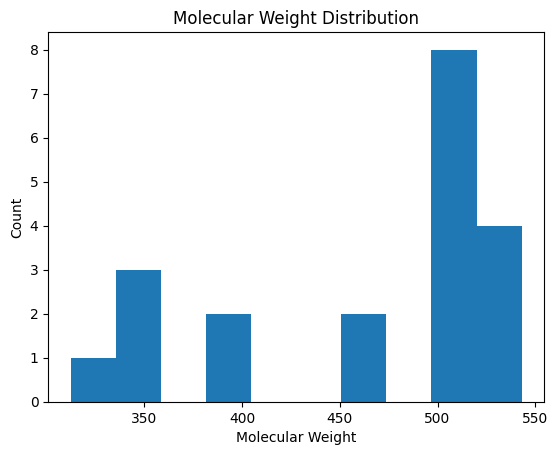

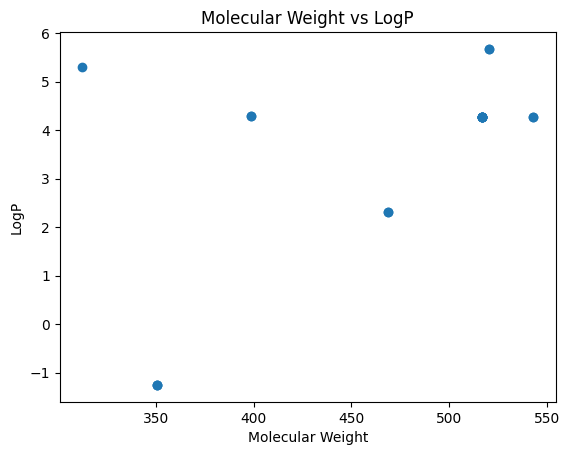

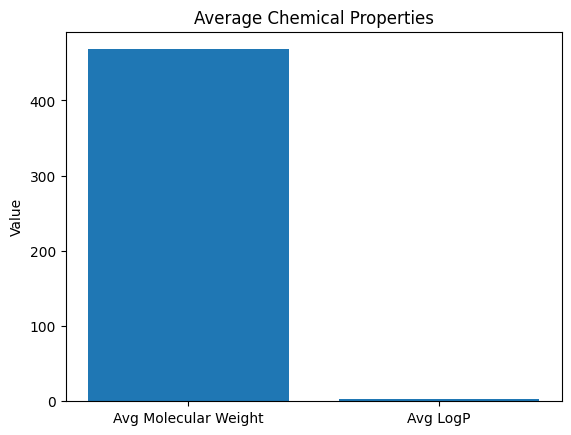

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# -------------------------------
# 1. Fetch data from ChEMBL
# -------------------------------
url = "https://www.ebi.ac.uk/chembl/api/data/activity.json?limit=20"
data = requests.get(url).json()

records = []

for item in data["activities"]:
    smi = item.get("canonical_smiles")
    if smi:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            mw = Descriptors.MolWt(mol)
            logp = Descriptors.MolLogP(mol)

            records.append({
                "molecular_weight": mw,
                "logP": logp
            })

df = pd.DataFrame(records)

print(df.head())

# -------------------------------
# 2. Histogram (Molecular Weight)
# -------------------------------
plt.figure()
plt.hist(df["molecular_weight"], bins=10)
plt.title("Molecular Weight Distribution")
plt.xlabel("Molecular Weight")
plt.ylabel("Count")
plt.show()

# -------------------------------
# 3. Scatter Plot (MW vs LogP)
# -------------------------------
plt.figure()
plt.scatter(df["molecular_weight"], df["logP"])
plt.title("Molecular Weight vs LogP")
plt.xlabel("Molecular Weight")
plt.ylabel("LogP")
plt.show()

# -------------------------------
# 4. Bar Chart (Average values)
# -------------------------------
means = [df["molecular_weight"].mean(), df["logP"].mean()]
labels = ["Avg Molecular Weight", "Avg LogP"]

plt.figure()
plt.bar(labels, means)
plt.title("Average Chemical Properties")
plt.ylabel("Value")
plt.show()